In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/raw_exoplanets.csv")

missing_pct = (df.isna().sum() / len(df) * 100).sort_values(ascending=False)
print(missing_pct.round(2))

st_spectype    63.02
st_age         22.71
pl_orbeccen    16.69
pl_insol        9.15
pl_eqt          8.27
pl_orbsmax      6.75
st_rad          5.05
st_teff         4.67
pl_rade         0.79
pl_bmasse       0.49
st_mass         0.14
disc_year       0.02
pl_name         0.00
hostname        0.00
dtype: float64


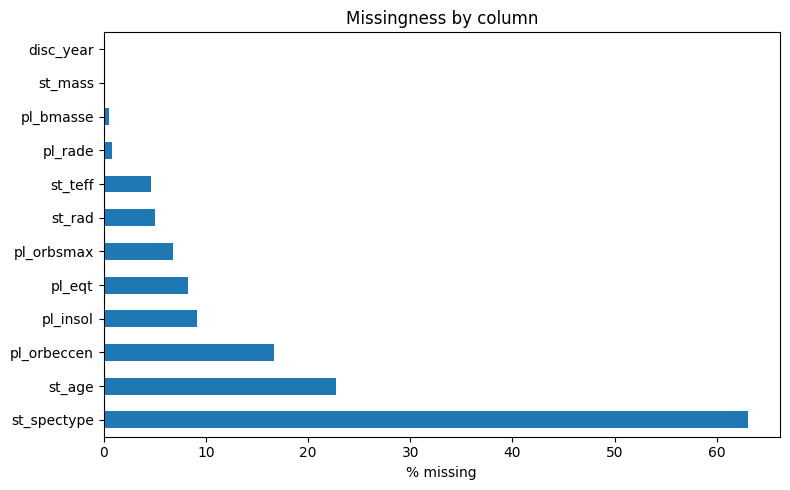

In [2]:
import matplotlib.pyplot as plt

missing_pct[missing_pct > 0].plot(kind='barh', figsize=(8,5))
plt.xlabel("% missing")
plt.title("Missingness by column")
plt.tight_layout()
plt.show()

In [3]:
core_cols = ['pl_insol', 'pl_eqt', 'pl_rade', 'pl_orbeccen', 'pl_bmasse', 'st_spectype']
non_null_count = df[core_cols].notna().sum(axis=1)

print(non_null_count.value_counts().sort_index())
print(f"\nPlanets with >=4 of 6 core inputs: {(non_null_count >= 4).sum()} / {len(df)}")

0       3
1       3
2     387
3     148
4     381
5    3411
6    1965
Name: count, dtype: int64

Planets with >=4 of 6 core inputs: 5757 / 6298


In [4]:
counts = non_null_count.value_counts().sort_index()
print(counts)
print(f"\nTotal retained (>=4): {(non_null_count >= 4).sum()}")
print(f"Dropped (<4): {(non_null_count < 4).sum()} ({(non_null_count < 4).sum()/len(df)*100:.1f}%)")

0       3
1       3
2     387
3     148
4     381
5    3411
6    1965
Name: count, dtype: int64

Total retained (>=4): 5757
Dropped (<4): 541 (8.6%)


## Inclusion threshold decision

**Rule:** A planet is retained if it has non-null values for at least 4 of the 6 core 
scoring inputs (`pl_insol`, `pl_eqt`, `pl_rade`, `pl_orbeccen`, `pl_bmasse`, `st_spectype`).

**Result:** 5,757 of 6,298 planets retained (91.4%). The remaining 541 planets (8.6%) 
are dropped due to insufficient data for meaningful scoring.

**Rationale:** `st_spectype` alone is missing in ~63% of all rows, but it only feeds 
one of six scoring factors (stellar stability). A stricter "must have all 6" rule would 
have discarded far more usable planets over a single weak field. Instead, missing 
factors are skipped per-planet at scoring time, with weights re-normalized across 
whatever factors are available — so no planet is penalized for a field NASA simply 
hasn't measured yet, but planets with too little data overall are still excluded as 
unreliable.

In [6]:
df_filtered = df[non_null_count >= 4].copy()
print(df_filtered.shape)

import os
os.makedirs("../data", exist_ok=True)
df_filtered.to_csv("../data/filtered_exoplanets.csv", index=False)

(5757, 14)
